In [1]:
import pandas as pd
import numpy as np
import joblib  
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

duels = pd.read_parquet("data/defensive_duels_preprocessed.parquet")

defensive_duels = duels[duels.is_defensive_duel]
defensive_duels = defensive_duels[defensive_duels.start_x<60]

defensive_duels["groundDuel_stoppedProgress"] = defensive_duels["groundDuel_stoppedProgress"] & ~defensive_duels["groundDuel_recoveredPossession"]

recovered = defensive_duels["groundDuel_recoveredPossession"].fillna(False).astype(bool)
stopped = defensive_duels["groundDuel_stoppedProgress"].fillna(False).astype(bool)

defensive_duels["duel_outcome"] = np.select(
    [recovered, stopped],
    ["recovered", "stopped"],
    default="beat",
)

C:\Users\zcoch\AppData\Local\Temp\ipykernel_3604\3415791542.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recovered = defensive_duels["groundDuel_recoveredPossession"].fillna(False).astype(bool)


In [2]:
from sklearn.preprocessing import LabelEncoder
le_duel_outcome = LabelEncoder()
duel_outcome_codes = le_duel_outcome.fit_transform(defensive_duels["duel_outcome"])
duel_outcome_names = le_duel_outcome.classes_
defensive_duels["duel_outcome_code"] = duel_outcome_codes

In [3]:
sop_cols = ["delta_x_30s","dist_30s","dist_ratio_30v60"]

df  = defensive_duels[["start_x","start_y"] + sop_cols + ["duel_outcome_code"] + ["outcome"]].dropna()
X = df.drop("outcome",axis=1)
y = df["outcome"] < 0 # Goal conceded is the "positive" class (1), i.e. the outcome we want to predict

In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=500,
    # scale_pos_weight=neg / pos,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="binary_logloss",
    categorical_feature=[4], # duel_outcome_code
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
)

[LightGBM] [Info] Number of positive: 10566, number of negative: 642375
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 652941, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016182 -> initscore=-4.107531
[LightGBM] [Info] Start training from score -4.107531
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[56]	valid_0's binary_logloss: 0.0742448


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,500


In [5]:
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

proba_cond = model.predict_proba(X_test)[:, 1]
print(f"Conditional model ROC AUC: {roc_auc_score(y_test, proba_cond):.4f}")
print(f"Conditional model PR AUC:  {average_precision_score(y_test, proba_cond):.5f}")
print(f"Conditional log loss:      {log_loss(y_test, proba_cond):.5f}")

Conditional model ROC AUC: 0.7667
Conditional model PR AUC:  0.07369
Conditional log loss:      0.07424


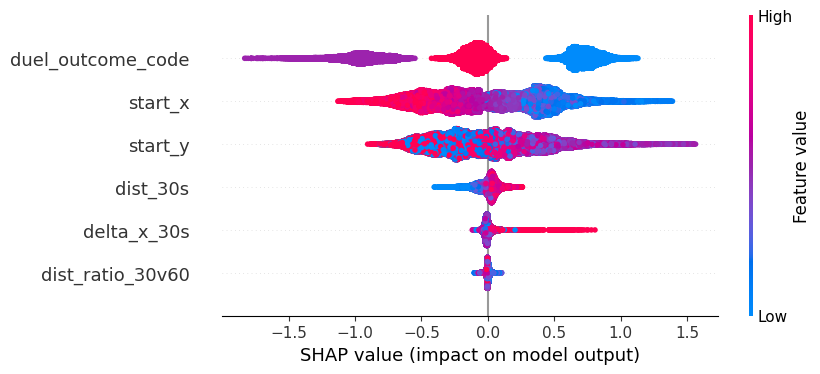

In [6]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [7]:
from mplsoccer import Pitch

outcome_feat_cols = ["start_x", "start_y"] + sop_cols
X_outcome = df[outcome_feat_cols].to_numpy()
y_outcome = df["duel_outcome_code"].to_numpy()

oX_train, oX_test, oy_train, oy_test = train_test_split(
    X_outcome, y_outcome, test_size=0.2, random_state=42, stratify=y_outcome
)

outcome_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(duel_outcome_names),
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=500,
    random_state=42,
    n_jobs=-1,
)
outcome_model.fit(
    oX_train, oy_train,
    eval_set=[(oX_test, oy_test)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
)

x_lo, x_hi = 0, 60
y_lo, y_hi = 0, 80
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 120), np.linspace(y_lo, y_hi, 100))
grid_xy = np.column_stack([gx.ravel(), gy.ravel()])

pitch = Pitch(pitch_type="statsbomb", line_color="white", pitch_color="#22312b", linewidth=1.2)

sop_arr = df[sop_cols].to_numpy()
sop_median = np.median(sop_arr, axis=0)
sop_low = np.quantile(sop_arr, 0.10, axis=0)
sop_high = np.quantile(sop_arr, 0.90, axis=0)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 652941, number of used features: 5
[LightGBM] [Info] Start training from score -1.040364
[LightGBM] [Info] Start training from score -1.438952
[LightGBM] [Info] Start training from score -0.892823
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[70]	valid_0's multi_logloss: 1.06578


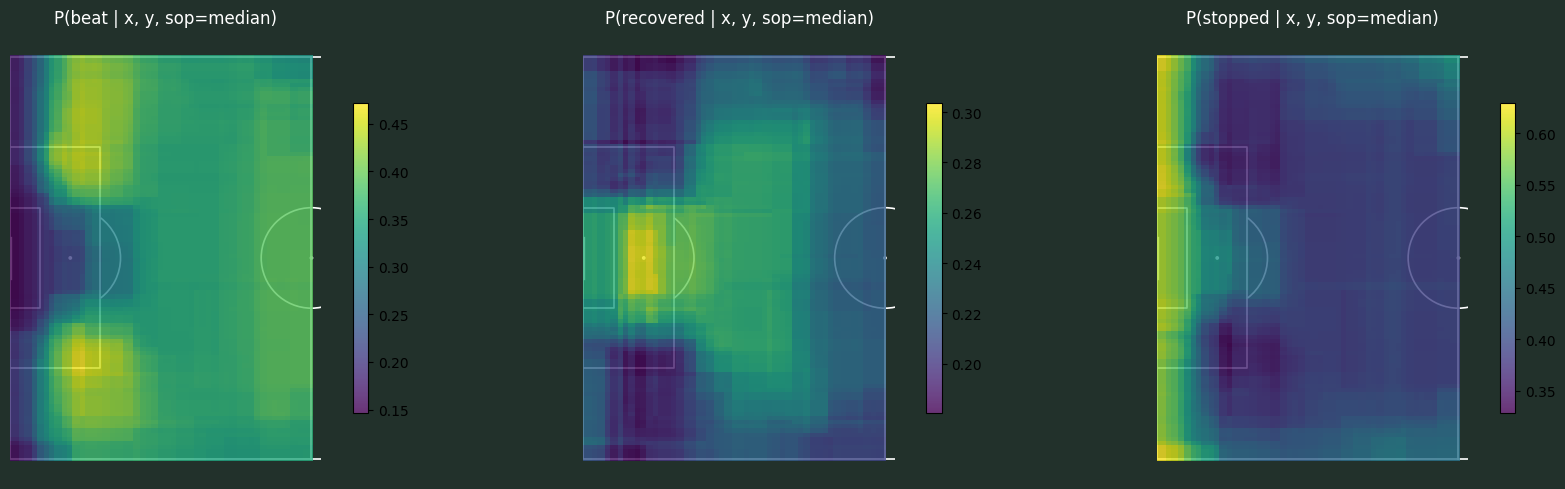

In [8]:
grid_feat = np.column_stack([grid_xy, np.tile(sop_median, (len(grid_xy), 1))])
grid_outcome_p = outcome_model.predict_proba(grid_feat)

fig, axes = plt.subplots(1, len(duel_outcome_names), figsize=(6 * len(duel_outcome_names), 5))
for i, (ax, cls) in enumerate(zip(axes, duel_outcome_names)):
    pitch.draw(ax=ax)
    p = grid_outcome_p[:, i].reshape(gx.shape)
    im = ax.pcolormesh(gx, gy, p, cmap="viridis", shading="auto", alpha=0.8, zorder=1)
    ax.set_xlim(0, 62)
    ax.set_title(f"P({cls} | x, y, sop=median)", color="white", pad=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

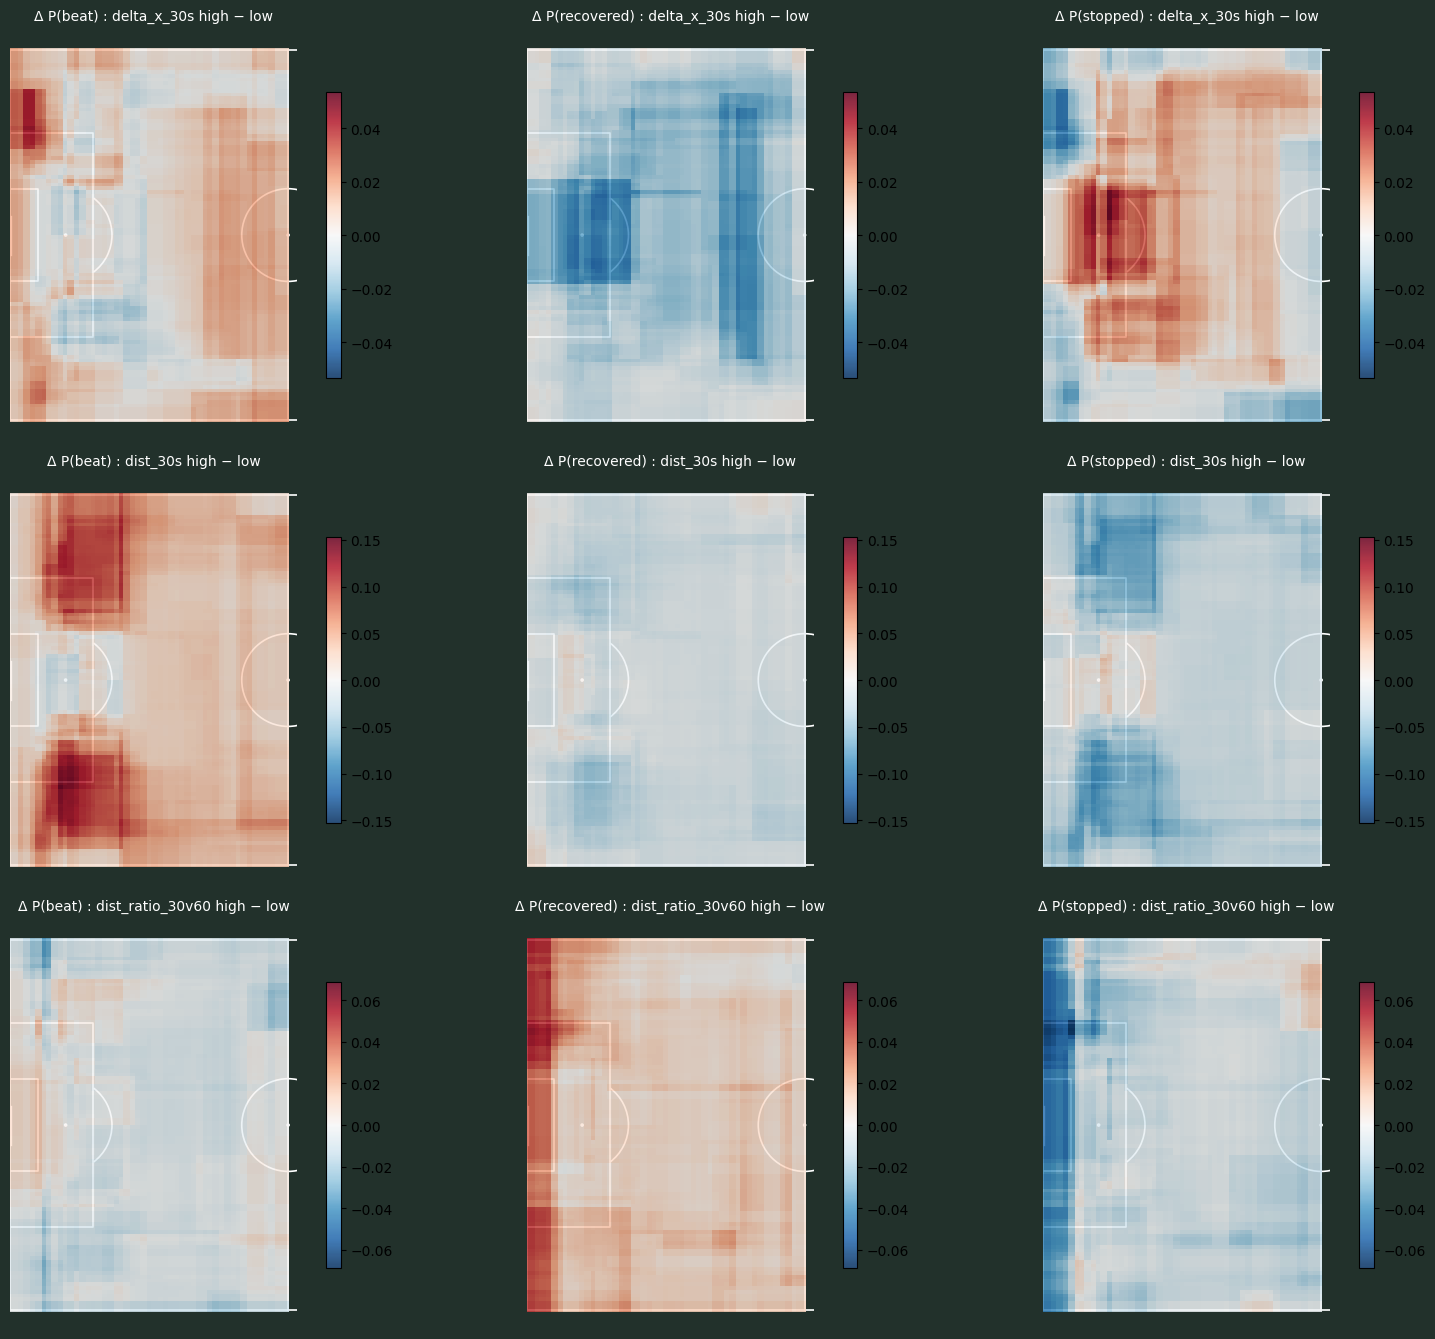

In [9]:
n_out = len(duel_outcome_names)
n_sop = len(sop_cols)

fig, axes = plt.subplots(n_sop, n_out, figsize=(5.5 * n_out, 4.5 * n_sop), squeeze=False)

for s, sop_feat in enumerate(sop_cols):
    low_feat = sop_median.copy();  low_feat[s]  = sop_low[s]
    high_feat = sop_median.copy(); high_feat[s] = sop_high[s]

    p_low  = outcome_model.predict_proba(np.column_stack([grid_xy, np.tile(low_feat,  (len(grid_xy), 1))]))
    p_high = outcome_model.predict_proba(np.column_stack([grid_xy, np.tile(high_feat, (len(grid_xy), 1))]))
    diff = p_high - p_low

    vmax = np.abs(diff).max()
    for o, cls in enumerate(duel_outcome_names):
        ax = axes[s, o]
        pitch.draw(ax=ax)
        d = diff[:, o].reshape(gx.shape)
        im = ax.pcolormesh(gx, gy, d, cmap="RdBu_r", shading="auto",
                           vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1)
        ax.set_xlim(0, 62)
        ax.set_title(f"Δ P({cls}) : {sop_feat} high − low", color="white", pad=8, fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.7)

fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

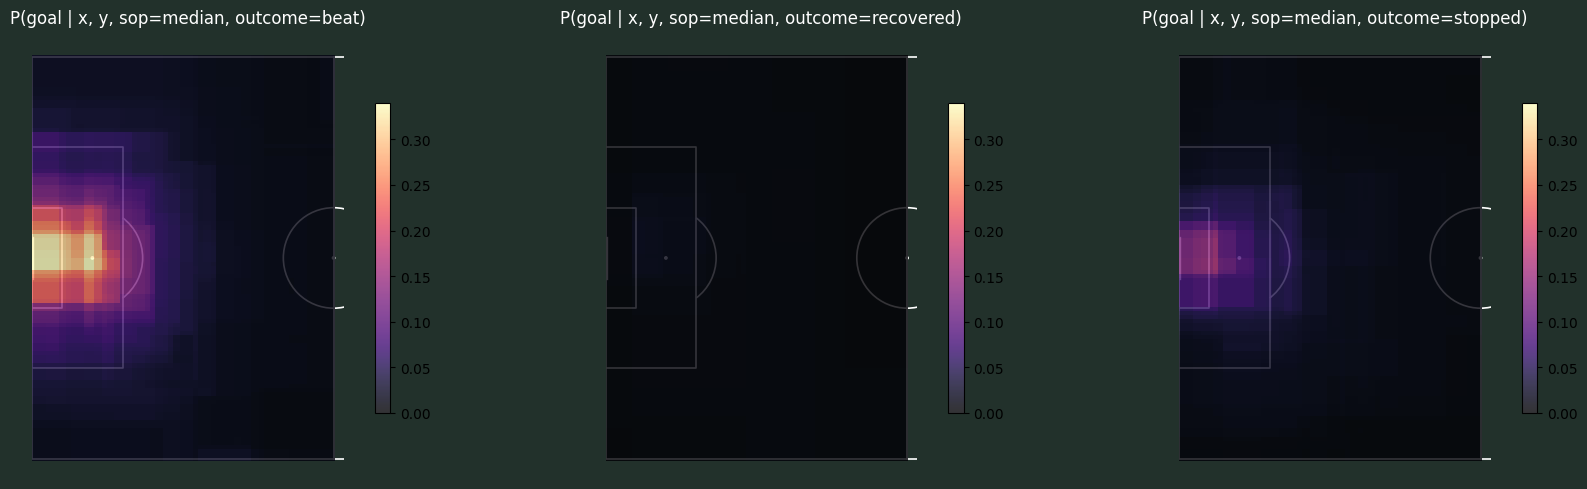

In [10]:
goal_surfaces = []
for c in range(len(duel_outcome_names)):
    g = np.column_stack([
        grid_xy,
        np.tile(sop_median, (len(grid_xy), 1)),
        np.full(len(grid_xy), c),
    ])
    goal_surfaces.append(model.predict_proba(g)[:, 1].reshape(gx.shape))

vmax = max(s.max() for s in goal_surfaces)

fig, axes = plt.subplots(1, len(duel_outcome_names), figsize=(6 * len(duel_outcome_names), 5))
for i, (ax, cls) in enumerate(zip(axes, duel_outcome_names)):
    pitch.draw(ax=ax)
    im = ax.pcolormesh(gx, gy, goal_surfaces[i],
                       cmap="magma", shading="auto",
                       vmin=0, vmax=vmax, alpha=0.8, zorder=1)
    ax.set_xlim(0, 62)
    ax.set_title(f"P(goal | x, y, sop=median, outcome={cls})", color="white", pad=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

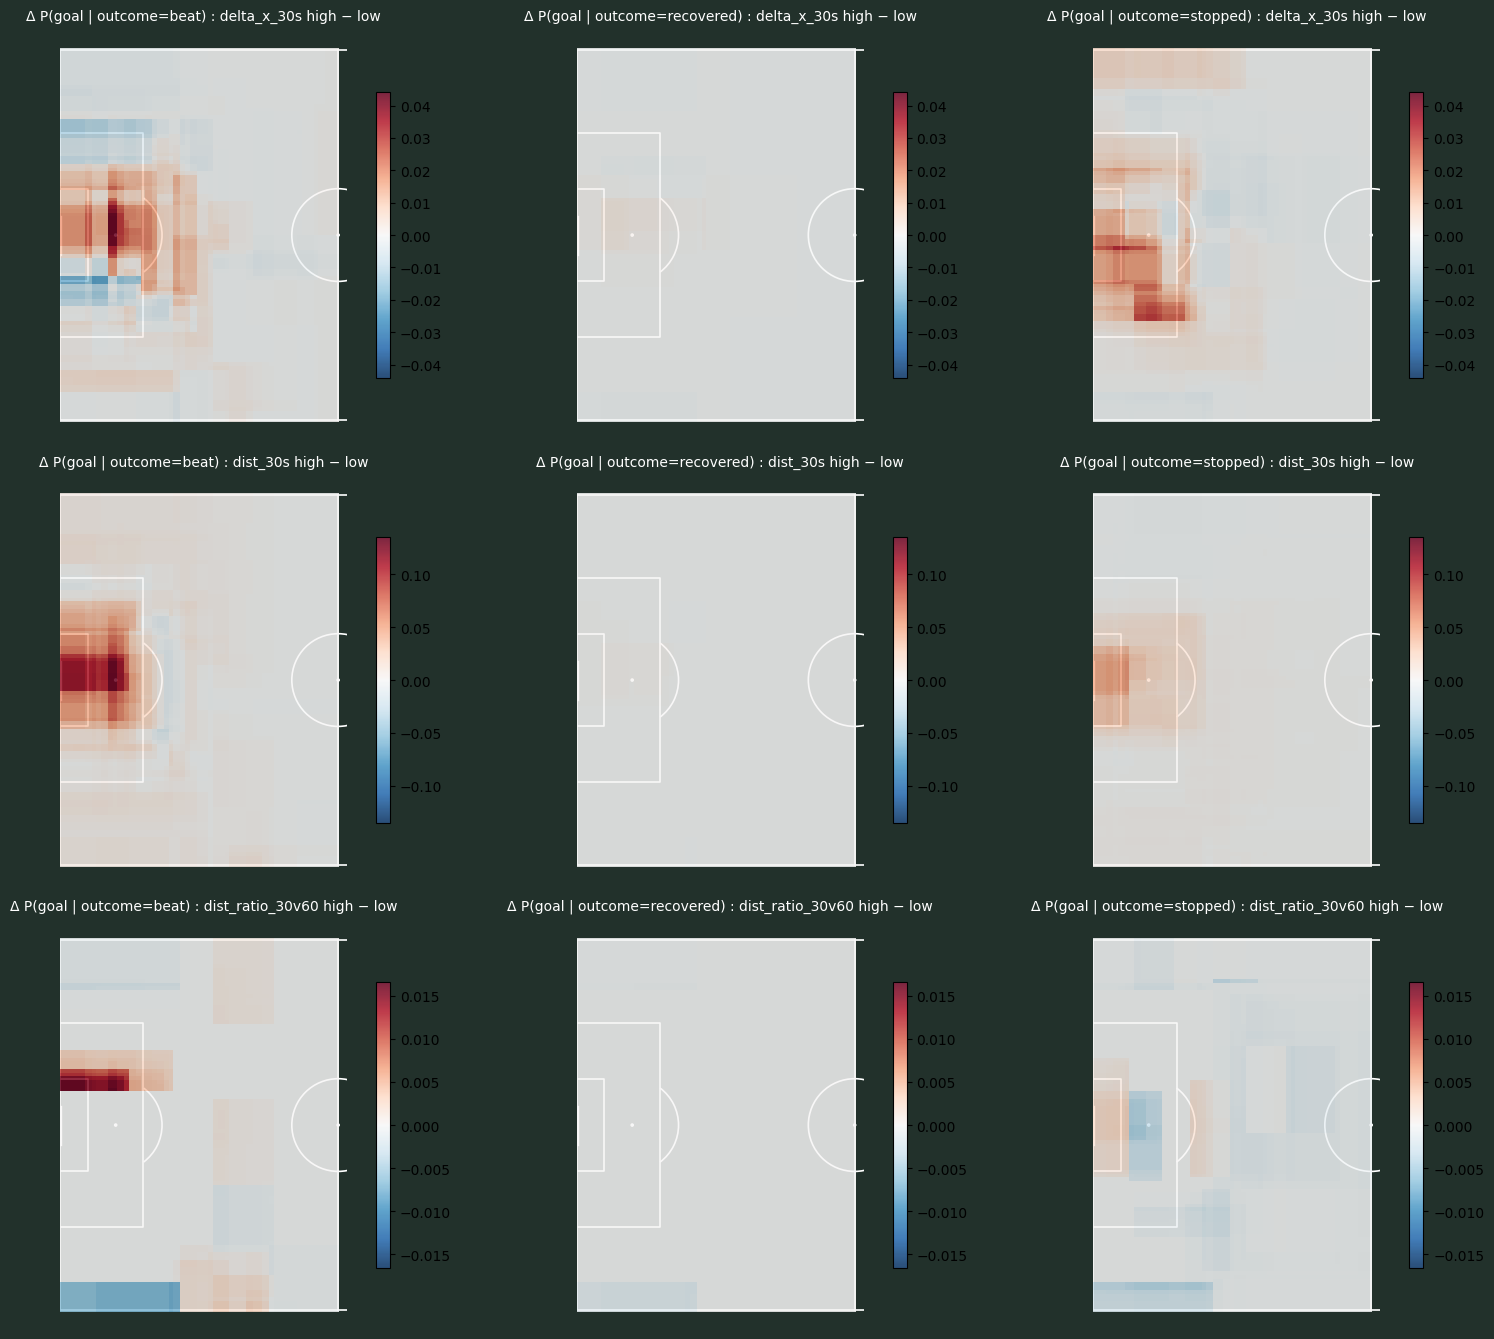

In [11]:
fig, axes = plt.subplots(n_sop, n_out, figsize=(5.5 * n_out, 4.5 * n_sop), squeeze=False)

for s, sop_feat in enumerate(sop_cols):
    low_feat = sop_median.copy();  low_feat[s]  = sop_low[s]
    high_feat = sop_median.copy(); high_feat[s] = sop_high[s]

    per_outcome_diff = []
    for c in range(n_out):
        g_low  = np.column_stack([grid_xy, np.tile(low_feat,  (len(grid_xy), 1)), np.full(len(grid_xy), c)])
        g_high = np.column_stack([grid_xy, np.tile(high_feat, (len(grid_xy), 1)), np.full(len(grid_xy), c)])
        p_low  = model.predict_proba(g_low)[:, 1]
        p_high = model.predict_proba(g_high)[:, 1]
        per_outcome_diff.append(p_high - p_low)

    vmax = max(np.abs(d).max() for d in per_outcome_diff)
    for o, cls in enumerate(duel_outcome_names):
        ax = axes[s, o]
        pitch.draw(ax=ax)
        d = per_outcome_diff[o].reshape(gx.shape)
        im = ax.pcolormesh(gx, gy, d, cmap="RdBu_r", shading="auto",
                           vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1)
        ax.set_xlim(0, 62)
        ax.set_title(f"Δ P(goal | outcome={cls}) : {sop_feat} high − low",
                     color="white", pad=8, fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.7)

fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

In [12]:
X_xy_sop = df[outcome_feat_cols].to_numpy()  # (N, 5): [x, y, *sop_cols]
observed_outcome_codes = df["duel_outcome_code"].to_numpy()

p_outcomes = outcome_model.predict_proba(X_xy_sop)  # (N, 3): p(c | x, y, sop)

p_goal_per_outcome = np.column_stack([
    model.predict_proba(np.column_stack([X_xy_sop, np.full(len(X_xy_sop), i)]))[:, 1]
    for i in range(len(duel_outcome_names))
])  # (N, 3): p(goal | x, y, sop, c) for each possible c

expected_danger = (p_outcomes * p_goal_per_outcome).sum(axis=1)
realized_danger = p_goal_per_outcome[np.arange(len(X_xy_sop)), observed_outcome_codes]
duel_value = expected_danger - realized_danger  # positive = defender averted danger vs expected

defensive_duels = defensive_duels.assign(
    duel_value=pd.Series(duel_value, index=df.index)
)

print(f"Mean value: {duel_value.mean():+.6e}")
print(f"Std  value: {duel_value.std():.6e}")
print()
print("Mean value by observed outcome:")
for i, cls in enumerate(duel_outcome_names):
    mask = observed_outcome_codes == i
    print(f"  {cls:10s}  mean={duel_value[mask].mean():+.6e}  n={mask.sum():,}")


Mean value: +6.643338e-05
Std  value: 1.637264e-02

Mean value by observed outcome:
  beat        mean=-1.275626e-02  n=288,376
  recovered   mean=+1.241891e-02  n=193,578
  stopped     mean=+3.975765e-03  n=334,223


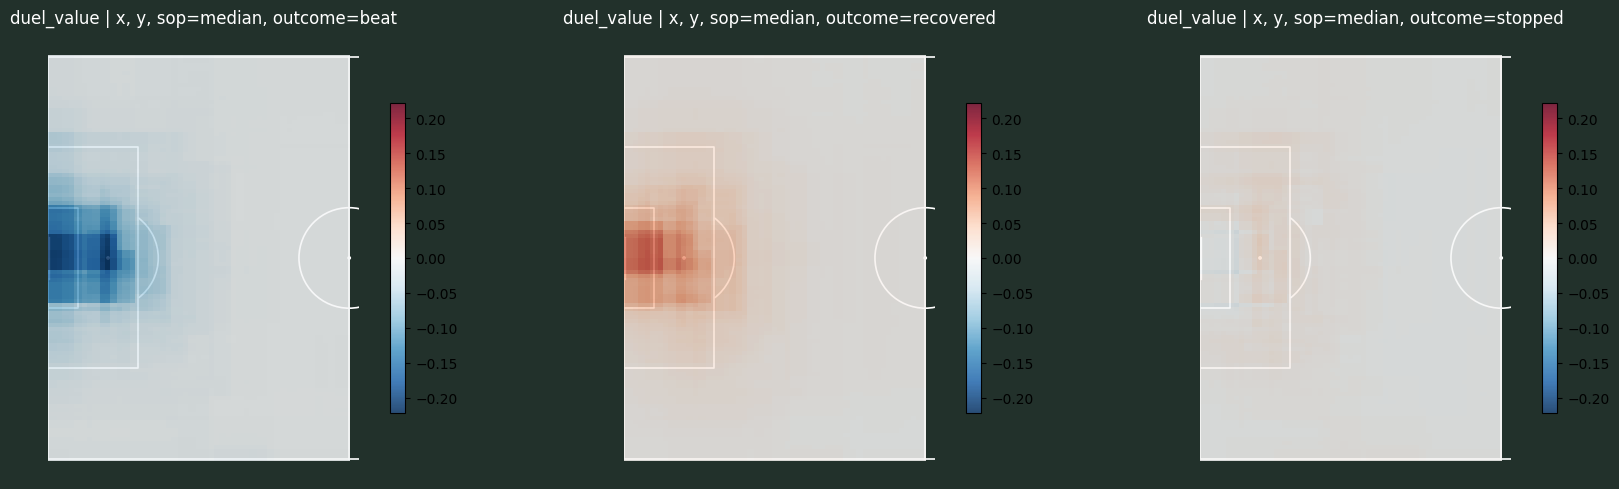

In [13]:
grid_feat_xy_sop = np.column_stack([grid_xy, np.tile(sop_median, (len(grid_xy), 1))])

grid_p_outcome = outcome_model.predict_proba(grid_feat_xy_sop)  # (G, n_out)
grid_p_goal_per_outcome = np.column_stack([
    model.predict_proba(np.column_stack([grid_feat_xy_sop, np.full(len(grid_xy), c)]))[:, 1]
    for c in range(len(duel_outcome_names))
])  # (G, n_out)

grid_expected_danger = (grid_p_outcome * grid_p_goal_per_outcome).sum(axis=1)  # (G,)
grid_duel_value = grid_expected_danger[:, None] - grid_p_goal_per_outcome  # (G, n_out)

vmax = np.abs(grid_duel_value).max()

fig, axes = plt.subplots(1, len(duel_outcome_names), figsize=(6 * len(duel_outcome_names), 5))
for i, (ax, cls) in enumerate(zip(axes, duel_outcome_names)):
    pitch.draw(ax=ax)
    v = grid_duel_value[:, i].reshape(gx.shape)
    im = ax.pcolormesh(gx, gy, v, cmap="RdBu_r", shading="auto",
                       vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1)
    ax.set_xlim(0, 62)
    ax.set_title(f"duel_value | x, y, sop=median, outcome={cls}", color="white", pad=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()


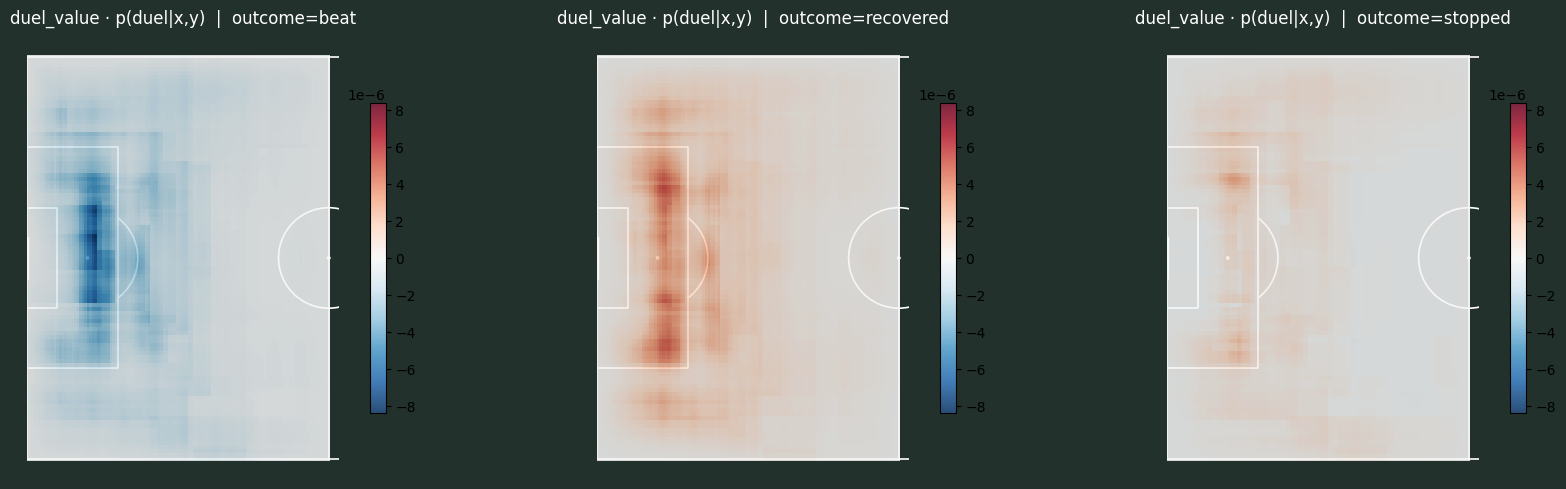

In [14]:
from scipy.ndimage import gaussian_filter

x_edges = np.linspace(x_lo, x_hi, gx.shape[1] + 1)
y_edges = np.linspace(y_lo, y_hi, gx.shape[0] + 1)
H, _, _ = np.histogram2d(
    df["start_x"].to_numpy(), df["start_y"].to_numpy(),
    bins=[x_edges, y_edges],
)
# histogram2d returns (nx, ny); transpose to (ny, nx) to match gx/gy meshgrid
p_duel_grid = gaussian_filter(H.T.astype(float), sigma=2.0)
p_duel_grid /= p_duel_grid.sum()

p_duel_xy = p_duel_grid.ravel()  # (G,)
grid_duel_value_weighted = grid_duel_value * p_duel_xy[:, None]  # (G, n_out)

vmax = np.abs(grid_duel_value_weighted).max()

fig, axes = plt.subplots(1, len(duel_outcome_names), figsize=(6 * len(duel_outcome_names), 5))
for i, (ax, cls) in enumerate(zip(axes, duel_outcome_names)):
    pitch.draw(ax=ax)
    v = grid_duel_value_weighted[:, i].reshape(gx.shape)
    im = ax.pcolormesh(gx, gy, v, cmap="RdBu_r", shading="auto",
                       vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1)
    ax.set_xlim(0, 62)
    ax.set_title(f"duel_value · p(duel|x,y)  |  outcome={cls}", color="white", pad=10)
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.patch.set_facecolor("#22312b")
plt.tight_layout()
plt.show()


In [16]:
defensive_duels.to_parquet("data/defensive_duels_valued.parquet")